# Predicting the Impact of Power Outages on Togolese Businesses

## Machine Learning Project — Supervised Classification

---

**Author:** Hodabalo Kanaza  
**Program:** ALX Data Science Program  
**Date:** May 2026  
**Data Source:** Survey by the Ministry of Economy and Strategic Watch of Togo (DGEAE, 2025)

---

## Project Objective

This project aims to **predict the level of impact of electricity supply disruptions** on Togolese businesses, based on their sector characteristics, electricity usage patterns, and adaptation strategies.

### Research Question
> *To what extent do electricity supply disruptions affect the competitiveness of businesses in Togo?*

### Target Variable
The variable to predict is the **amplitude of the impact** of power outages, grouped into 3 classes:
- **Low** : No disruption or less than 10% activity loss
- **Moderate** : Between 10% and 25% activity loss
- **High** : More than 25% activity loss

### Approach
We compare **4 classification algorithms**:
1. Decision Tree (baseline)
2. Random Forest
3. Gradient Boosting
4. Logistic Regression

---

## 0. Importing Libraries

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_recall_fscore_support
)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'Low': '#27AE60', 'Moderate': '#E67E22', 'High': '#C0392B'}
PALETTE = ['#27AE60', '#E67E22', '#C0392B']
CLASS_ORDER = ['Low', 'Moderate', 'High']

print('All libraries imported successfully!')
import sklearn
print(f'  NumPy        : {np.__version__}')
print(f'  Pandas       : {pd.__version__}')
print(f'  Scikit-learn : {sklearn.__version__}')


All libraries imported successfully!
  NumPy        : 2.3.5
  Pandas       : 2.3.3
  Scikit-learn : 1.8.0


---
## 1. Data Loading and Initial Exploration

### 1.1 Survey Context

The data comes from the **Q2 2025 business survey** conducted by the DGEAE in Togo.

- **Sample**: 172 formal businesses
- **Method**: Stratification by business sector (Cut-Off method)
- **Collection**: Physical questionnaire administered to business managers


In [2]:
# Load the dataset
# Adjust the path if necessary
FILE_PATH = 'data_electricite.xlsx'

df_raw = pd.read_excel(FILE_PATH, sheet_name='Feuil1')

print(f'Dataset dimensions: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print()
print('Available columns:')
print(df_raw.columns.tolist())


Dataset dimensions: 170 rows x 34 columns

Available columns:
['id', 'Section', 'Classe', 'Secteur', 'Poids', 'Z1', 'Z21', 'Z22', 'Z23', 'Z24', 'Z25', 'Autres Z2', 'Z3', 'Z41', 'Z42', 'Z43', 'Z44', 'Z45', 'Z46', 'Z47', 'Z48', 'Autres Z4', 'Z5', 'Z61', 'Z62', 'Z63', 'Z64', 'Z65', 'Z66', 'Autres Z6', 'Z7', 'Z8', 'Poids2', 'Poids3']


In [3]:
# First 5 rows
df_raw.head(5)


,id,Section,Classe,Secteur,Poids,Z1,Z21,Z22,Z23,Z24,...,Z62,Z63,Z64,Z65,Z66,Autres Z6,Z7,Z8,Poids2,Poids3
0,E1,C,11.01,Industrie,0.165023,OUI,1,1,1,0,...,1.0,0.0,0.0,0.0,0.0,NaN,Plus de 75%,Elevé,0.086654,0.055008
1,E2,C,25.10,Industrie,0.000005,NON,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,NaN,Plus de 75%,Moyen,0.000003,0.000002
2,E3,C,27.20,Industrie,0.000160,OUI,1,1,1,0,...,0.0,0.0,1.0,1.0,0.0,NaN,[50-75[%,Elevé,0.000084,0.000053
3,E4,B,8.10,Industrie,0.010398,OUI,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.002033,0.003466
4,E5,C,23.31,Industrie,0.116969,NON,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.061421,0.038990


In [4]:
# General information
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         170 non-null    object 
 1   Section    170 non-null    object 
 2   Classe     170 non-null    float64
 3   Secteur    170 non-null    object 
 4   Poids      170 non-null    float64
 5   Z1         170 non-null    object 
 6   Z21        170 non-null    int64  
 7   Z22        170 non-null    int64  
 8   Z23        170 non-null    int64  
 9   Z24        170 non-null    int64  
 10  Z25        170 non-null    int64  
 11  Autres Z2  6 non-null      object 
 12  Z3         170 non-null    object 
 13  Z41        170 non-null    int64  
 14  Z42        170 non-null    int64  
 15  Z43        170 non-null    int64  
 16  Z44        170 non-null    int64  
 17  Z45        170 non-null    int64  
 18  Z46        170 non-null    int64  
 19  Z47        170 non-null    int64  
 20  Z48       

In [5]:
# Missing values per column
missing = df_raw.isnull().sum().sort_values(ascending=False)
print('Missing values (top 15):')
print(missing.head(15))


Missing values (top 15):
Autres Z6    169
Autres Z2    164
Autres Z4    145
Z8            43
Z5            39
Z7             8
Z64            1
Z66            1
Z65            1
Z63            1
Z62            1
Z61            1
Z48            0
id             0
Z46            0
dtype: int64


---
## 2. Data Preprocessing and Cleaning

### 2.1 Variable Description

| Variable | Description | Type |
|---|---|---|
| Section | NAEMA sector code | Categorical |
| Z1 | Uses CEET electricity | Binary YES/NO |
| Z21-Z24 | Electricity uses | Binary 0/1 |
| Z3 | Experienced disruptions | Binary YES/NO |
| Z42-Z47 | Consequences of disruptions | Binary 0/1 |
| **Z5** | **Impact amplitude (TARGET)** | **Ordinal** |
| Z61-Z64 | Adaptation strategies | Binary 0/1 |
| Z7 | Coverage of needs by alternative measures | Ordinal |
| Z8 | Cost of adaptation measures | Ordinal |


### 2.2 Cleaning and Encoding

In [6]:
# Working copy
df = df_raw.copy()

# Sector mapping (NAEMA codes -> labels)
sector_map = {
    'B': 'Industry',              # Extractive industries
    'C': 'Industry',              # Manufacturing
    'D': 'Industry',              # Energy / Water
    'E': 'Industry',              # Waste management
    'F': 'Construction',          # Construction (BTP)
    'G': 'Trade_Storage',         # Trade / Transport
    'H': 'Transport',             # Land transport
    'I': 'HBR'                    # Hotels, Bars, Restaurants
}
df['Sector'] = df['Section'].map(sector_map)

print('Sector distribution:')
print(df['Sector'].value_counts(dropna=False))


Sector distribution:
Sector
Trade_Storage    63
Industry         48
Construction     20
Transport        20
HBR              19
Name: count, dtype: int64


In [7]:
# Clean target variable Z5
df['Z5'] = df['Z5'].astype(str).str.strip()
df['Z5'] = df['Z5'].replace({'25-50': '[25-50[%', 'nan': np.nan, '': np.nan})

print('Raw Z5 distribution:')
print(df['Z5'].value_counts(dropna=False))


Raw Z5 distribution:
Z5
[10-25[%        57
NaN             39
Moins de 10%    38
[25-50[%        27
Aucun            5
Plus de 50%      4
Name: count, dtype: int64


In [8]:
def regroup_impact(val):
    '''
    Groups Z5 modalities into 3 classes:
    - Low      : None or < 10% loss
    - Moderate : Between 10% and 25%
    - High     : > 25%
    '''
    if pd.isna(val): return np.nan
    if val in ['Aucune', 'Moins de 10%']: return 'Low'
    if val == '[10-25[%': return 'Moderate'
    if val in ['[25-50[%', 'Plus de 50%']: return 'High'
    return np.nan

df['Impact'] = df['Z5'].apply(regroup_impact)

print('Target variable distribution (after grouping):')
print(df['Impact'].value_counts(dropna=False))
print(f'Total with Impact recorded: {df["Impact"].notna().sum()}')


Target variable distribution (after grouping):
Impact
Moderate    57
NaN         44
Low         38
High        31
Name: count, dtype: int64
Total with Impact recorded: 126


In [9]:
# Encode numeric binary columns
binary_num_cols = ['Z21','Z22','Z23','Z24','Z44','Z45','Z46','Z47','Z61','Z62','Z63','Z64']
for c in binary_num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Encode text columns (YES/NO or '1'/'0' strings)
def encode_text_col(col):
    mapping = {'1':1,'0':0,'OUI':1,'NON':0,'nan':np.nan,'':np.nan,'  ':np.nan,' ':np.nan}
    return pd.to_numeric(col.astype(str).str.strip().map(mapping), errors='coerce')

for c in ['Z41','Z42','Z43']:
    if df[c].dtype == object:
        df[c] = encode_text_col(df[c])
    else:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Uses_CEET']   = df['Z1'].astype(str).str.strip().map({'OUI':1,'NON':0,'1':1,'0':0})
df['Had_disruption'] = df['Z3'].astype(str).str.strip().map({'OUI':1,'NON':0})

# Ordinal encoding
df['Coverage'] = df['Z7'].astype(str).str.strip().map(
    {'Moins de 25%':1, '[25-50[%':2, '[50-75[%':3, 'Plus de 75%':4})
df['Adapt_cost'] = df['Z8'].astype(str).str.strip().map(
    {'Faible':1, 'Moyen':2, 'Eleve':3, 'Insoutenable':4})

# Sector indicator variables
for s in ['Industry','Construction','HBR','Trade_Storage','Transport']:
    df[f'S_{s}'] = (df['Sector'] == s).astype(float)

print('Encoding complete!')


Encoding complete!


### 2.3 Building the Modeling Dataset

In [10]:
FEATURES = [
    # Electricity usage
    'Uses_CEET', 'Had_disruption', 'Z21', 'Z22', 'Z23', 'Z24',
    # Consequences
    'Z42', 'Z43', 'Z44', 'Z45', 'Z46', 'Z47',
    # Adaptation strategies
    'Z61', 'Z62', 'Z63', 'Z64',
    # Effectiveness and cost
    'Coverage', 'Adapt_cost',
    # Sector (one-hot)
    'S_Industry', 'S_Construction', 'S_HBR', 'S_Trade_Storage', 'S_Transport'
]

FEAT_LABELS = {
    'Uses_CEET':          'Uses CEET electricity',
    'Had_disruption':     'Experienced disruptions',
    'Z21':                'Usage: Air conditioning',
    'Z22':                'Usage: Lighting',
    'Z23':                'Usage: Direct production',
    'Z24':                'Usage: Equipment charging',
    'Z42':                'Consq: Production stoppage',
    'Z43':                'Consq: Delivery delays',
    'Z44':                'Consq: Material losses',
    'Z45':                'Consq: Financial losses',
    'Z46':                'Consq: Loss of competitiveness',
    'Z47':                'Consq: Cost increases',
    'Z61':                'Adapt: Solar energy',
    'Z62':                'Adapt: Generator',
    'Z63':                'Adapt: Battery/UPS',
    'Z64':                'Adapt: Schedule adjustment',
    'Coverage':           'Alternative needs coverage',
    'Adapt_cost':         'Adaptation cost',
    'S_Industry':         'Sector: Industry',
    'S_Construction':     'Sector: Construction',
    'S_HBR':              'Sector: Hotels/Bars/Restaurants',
    'S_Trade_Storage':    'Sector: Trade/Storage',
    'S_Transport':        'Sector: Transport'
}

# Final dataset (rows with Impact recorded)
model_df = df[FEATURES + ['Impact','Sector']].dropna(subset=['Impact']).reset_index(drop=True)
print(f'Modeling dataset: {model_df.shape[0]} businesses x {len(FEATURES)} features')

# Remaining missing values
missing = model_df[FEATURES].isnull().sum()
print('Remaining missing values:')
print(missing[missing > 0])


Modeling dataset: 126 businesses x 23 features
Remaining missing values:
Adapt_cost    43
dtype: int64


In [11]:
# Median imputation for remaining NaN values
X = model_df[FEATURES].to_numpy(dtype=float).copy()
for j in range(X.shape[1]):
    mask = np.isnan(X[:, j])
    if mask.any():
        med = np.nanmedian(X[:, j])
        X[mask, j] = med
        print(f'  Median imputation: {FEATURES[j]} -> {med:.1f} ({mask.sum()} values)')

y_raw = model_df['Impact'].values

# Encode target variable
le = LabelEncoder()
y  = le.fit_transform(y_raw)
class_names = le.classes_

print()
print(f'Encoded classes: {dict(zip(range(len(class_names)), class_names))}')
print(f'Class distribution: {dict(zip(class_names, np.bincount(y)))}')


  Median imputation: Adapt_cost -> 2.0 (43 values)

Encoded classes: {0: 'High', 1: 'Low', 2: 'Moderate'}
Class distribution: {'High': np.int64(31), 'Low': np.int64(38), 'Moderate': np.int64(57)}


---
## 3. Exploratory Data Analysis (EDA)

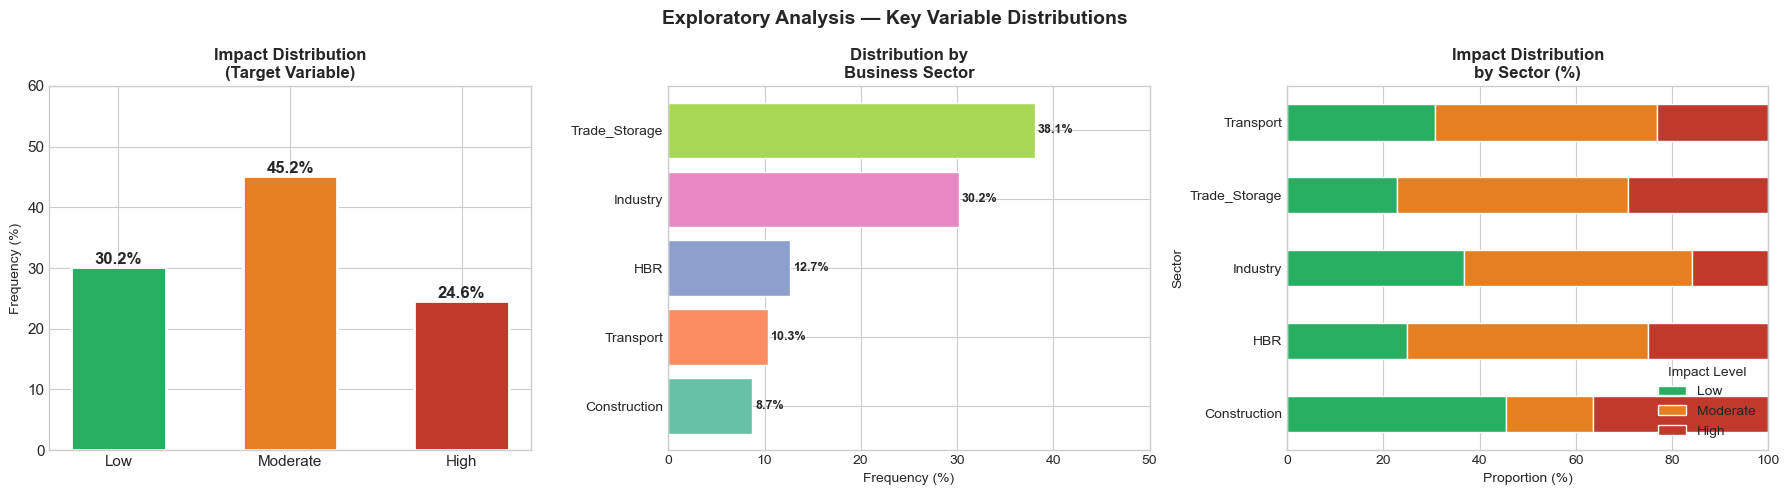

Figure 1 saved


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Analysis — Key Variable Distributions',
             fontsize=14, fontweight='bold')

# --- Fig 1: Target variable distribution (frequencies only) ---
ax = axes[0]
freq = pd.Series(y_raw).value_counts(normalize=True).reindex(CLASS_ORDER) * 100
bars = ax.bar(CLASS_ORDER, freq.values,
              color=[COLORS[k] for k in CLASS_ORDER],
              edgecolor='white', linewidth=2, width=0.55)
for b, v in zip(bars, freq.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5,
            f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Impact Distribution\n(Target Variable)', fontweight='bold')
ax.set_ylabel('Frequency (%)')
ax.set_ylim(0, 60)
ax.tick_params(labelsize=11)

# --- Fig 2: Distribution by sector (frequencies) ---
ax = axes[1]
sec_freq = (model_df['Sector'].value_counts(normalize=True) * 100).sort_values()
colors_s = sns.color_palette('Set2', len(sec_freq))
bars2 = ax.barh(sec_freq.index, sec_freq.values, color=colors_s, edgecolor='white')
for b, v in zip(bars2, sec_freq.values):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2,
            f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)
ax.set_title('Distribution by\nBusiness Sector', fontweight='bold')
ax.set_xlabel('Frequency (%)')
ax.set_xlim(0, 50)

# --- Fig 3: Impact by sector (stacked % bars) ---
ax = axes[2]
sec_impact = model_df.groupby(['Sector','Impact']).size().unstack(fill_value=0)
for imp in CLASS_ORDER:
    if imp not in sec_impact.columns: sec_impact[imp] = 0
sec_pct = sec_impact[CLASS_ORDER].div(sec_impact.sum(axis=1), axis=0) * 100
sec_pct.plot(kind='barh', stacked=True, color=PALETTE, ax=ax, edgecolor='white')
ax.set_title('Impact Distribution\nby Sector (%)', fontweight='bold')
ax.set_xlabel('Proportion (%)')
ax.set_xlim(0, 100)
ax.legend(title='Impact Level', loc='lower right')

plt.tight_layout()
plt.savefig('fig1_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')


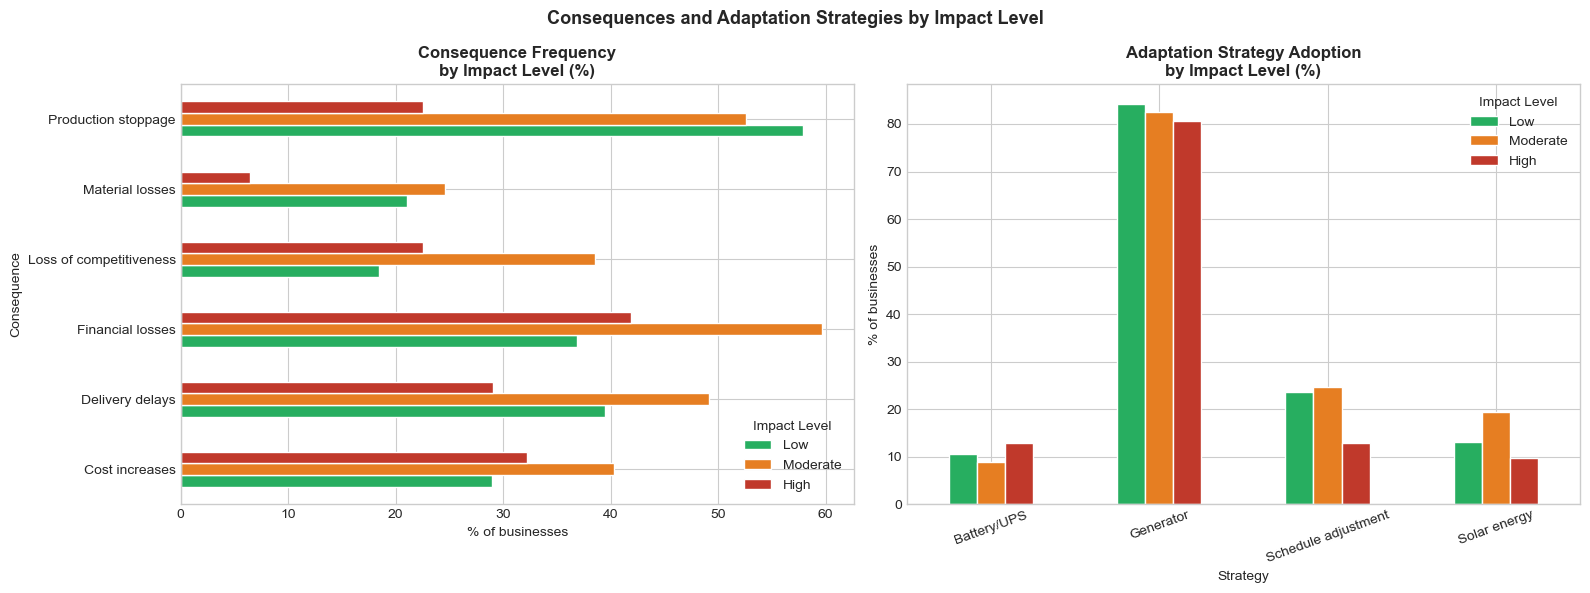

Figure 2 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Consequences and Adaptation Strategies by Impact Level',
             fontsize=13, fontweight='bold')

# --- Fig 4: Consequences by impact level (frequencies) ---
ax = axes[0]
consequences = {
    'Z42': 'Production stoppage',
    'Z43': 'Delivery delays',
    'Z44': 'Material losses',
    'Z45': 'Financial losses',
    'Z46': 'Loss of competitiveness',
    'Z47': 'Cost increases'
}
cdata = []
for z, lbl in consequences.items():
    for imp in CLASS_ORDER:
        sub = model_df[model_df['Impact'] == imp][z]
        cdata.append({'Consequence': lbl, 'Impact': imp, 'Frequency (%)': sub.mean() * 100})
cdf = pd.DataFrame(cdata).pivot(index='Consequence', columns='Impact', values='Frequency (%)').fillna(0)
cdf[CLASS_ORDER].plot(kind='barh', color=PALETTE, ax=ax, edgecolor='white')
ax.set_title('Consequence Frequency\nby Impact Level (%)', fontweight='bold')
ax.set_xlabel('% of businesses')
ax.legend(title='Impact Level')

# --- Fig 5: Adaptation strategies (frequencies) ---
ax = axes[1]
strats = {
    'Z61': 'Solar energy',
    'Z62': 'Generator',
    'Z63': 'Battery/UPS',
    'Z64': 'Schedule adjustment'
}
sdata = []
for z, lbl in strats.items():
    for imp in CLASS_ORDER:
        sub = model_df[model_df['Impact'] == imp][z]
        sdata.append({'Strategy': lbl, 'Impact': imp, 'Frequency (%)': sub.mean() * 100})
sdf = pd.DataFrame(sdata).pivot(index='Strategy', columns='Impact', values='Frequency (%)').fillna(0)
sdf[CLASS_ORDER].plot(kind='bar', color=PALETTE, ax=ax, edgecolor='white')
ax.set_title('Adaptation Strategy Adoption\nby Impact Level (%)', fontweight='bold')
ax.set_ylabel('% of businesses')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Impact Level')

plt.tight_layout()
plt.savefig('fig2_eda_consequences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')


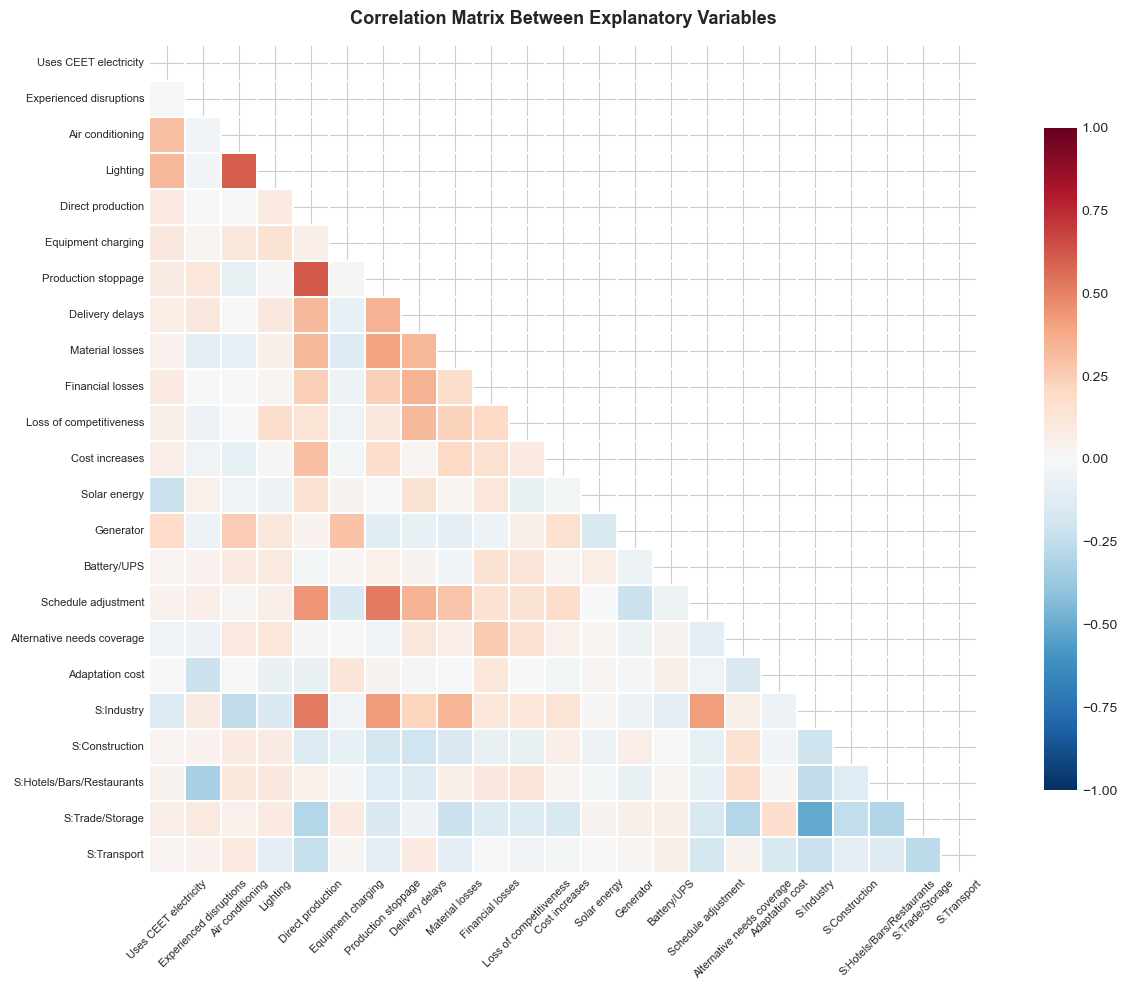

Figure 3 saved


In [14]:
# Correlation matrix between features
fig, ax = plt.subplots(figsize=(14, 10))
corr_df = pd.DataFrame(X, columns=FEATURES)
corr_m  = corr_df.corr()
mask = np.triu(np.ones_like(corr_m, dtype=bool))
short_labels = [
    FEAT_LABELS.get(f, f)
    .replace('Consq: ','').replace('Usage: ','').replace('Adapt: ','').replace('Sector: ','S:')
    for f in FEATURES
]
sns.heatmap(corr_m, mask=mask, cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.3,
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix Between Explanatory Variables',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')


---
## 4. Modeling — Training and Comparison

### 4.1 Train / Test Split
Stratified split to preserve class proportions in each set.


In [15]:
# 75% train / 25% test — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Dataset split:')
print(f'  Training set : {X_train.shape[0]} businesses ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test set     : {X_test.shape[0]} businesses ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution in training set:')
for i, cls in enumerate(class_names):
    n = (y_train == i).sum()
    print(f'  {cls:10s} : {n} ({n/len(y_train)*100:.0f}%)')


Dataset split:
  Training set : 94 businesses (75%)
  Test set     : 32 businesses (25%)

Class distribution in training set:
  High       : 23 (24%)
  Low        : 28 (30%)
  Moderate   : 43 (46%)


### 4.2 Model Definitions

In [17]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_split=5, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=42
    )
}
print('Models defined:')
for name in models: print(f'  - {name}')


Models defined:
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - Logistic Regression


### 4.3 Cross-Validation and Training

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Training in progress...')
print('-' * 70)
print(f'{"Model":<24} {"CV F1 Mean":<18} {"Test Acc.":<14} {"Test F1"}')
print('-' * 70)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {
        'CV_mean': cv_scores.mean(), 'CV_std': cv_scores.std(),
        'Accuracy': acc, 'F1': f1, 'model': model, 'y_pred': y_pred
    }
    print(f'{name:<24} {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}     {acc:.3f}         {f1:.3f}')

print('-' * 70)
best_name = max(results, key=lambda k: results[k]['F1'])
print(f'Best model: {best_name} (F1={results[best_name]["F1"]:.3f})')


Training in progress...
----------------------------------------------------------------------
Model                    CV F1 Mean         Test Acc.      Test F1
----------------------------------------------------------------------
Decision Tree            0.417 +/- 0.043     0.469         0.464
Random Forest            0.436 +/- 0.074     0.438         0.390
Gradient Boosting        0.444 +/- 0.068     0.438         0.439
Logistic Regression      0.451 +/- 0.079     0.406         0.391
----------------------------------------------------------------------
Best model: Decision Tree (F1=0.464)


---
## 5. Detailed Model Evaluation

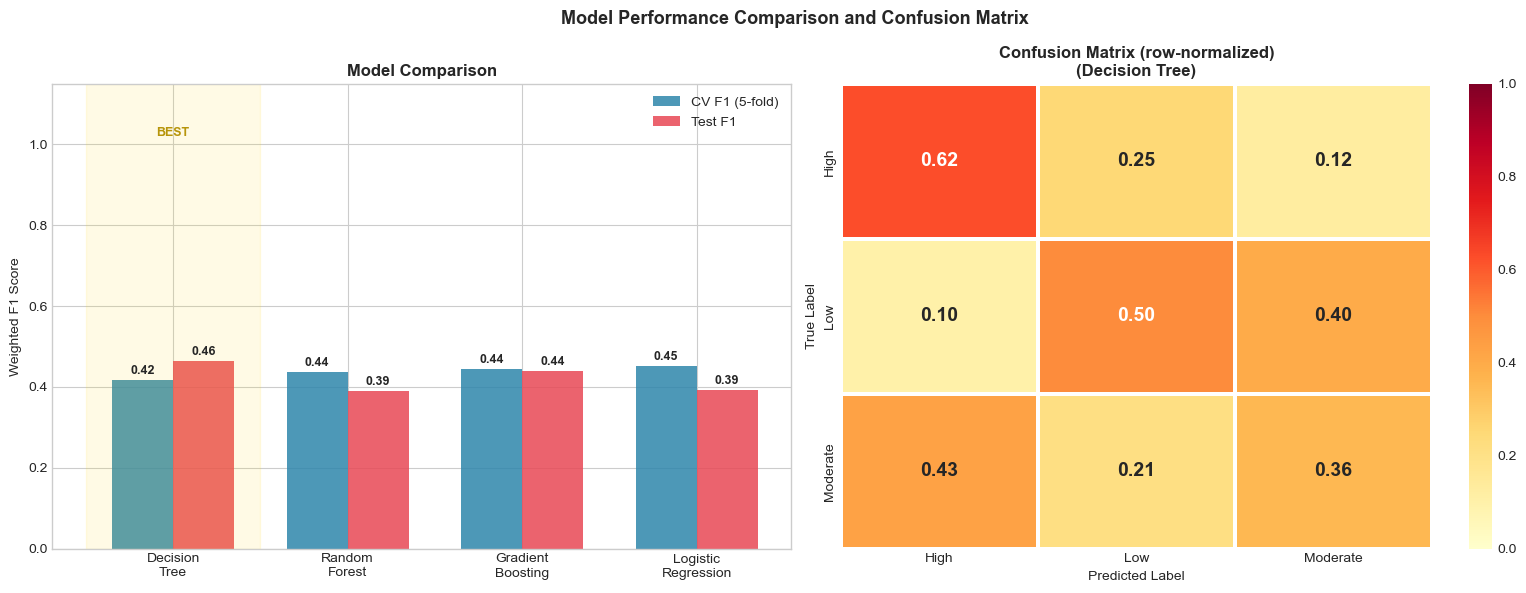

Figure 4 saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison and Confusion Matrix',
             fontsize=13, fontweight='bold')

# --- Model comparison (frequencies / scores only, no counts) ---
ax = axes[0]
names_s = ['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'Logistic\nRegression']
cv_v = [results[n]['CV_mean'] for n in models]
f1_v = [results[n]['F1']      for n in models]
x = np.arange(4); w = 0.35
b1 = ax.bar(x - w/2, cv_v, w, label='CV F1 (5-fold)', color='#2E86AB', alpha=0.85)
b2 = ax.bar(x + w/2, f1_v, w, label='Test F1',        color='#E84855', alpha=0.85)
for b, v in zip(list(b1) + list(b2), cv_v + f1_v):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
best_idx = list(models.keys()).index(best_name)
ax.axvspan(best_idx - 0.5, best_idx + 0.5, alpha=0.1, color='gold')
ax.text(best_idx, 1.02, 'BEST', ha='center', fontsize=9, color='#B7950B', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names_s, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_ylabel('Weighted F1 Score'); ax.legend()

# --- Confusion matrix (best model) ---
ax = axes[1]
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
# Show row-normalized confusion matrix (frequencies, not counts)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'},
            vmin=0, vmax=1)
ax.set_title(f'Confusion Matrix (row-normalized)\n({best_name})', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')


In [20]:
# Detailed classification report
print(f'DETAILED CLASSIFICATION REPORT -- {best_name}')
print('=' * 55)
print(classification_report(y_test, results[best_name]['y_pred'], target_names=class_names))


DETAILED CLASSIFICATION REPORT -- Decision Tree
              precision    recall  f1-score   support

        High       0.42      0.62      0.50         8
         Low       0.50      0.50      0.50        10
    Moderate       0.50      0.36      0.42        14

    accuracy                           0.47        32
   macro avg       0.47      0.49      0.47        32
weighted avg       0.48      0.47      0.46        32



In [21]:
# Summary table for all models
print('PERFORMANCE SUMMARY')
print('-' * 70)
print(f'{"Model":<24} {"CV F1":>9}  {"Std":>6}  {"Test Acc.":>10}  {"Test F1":>8}')
print('-' * 70)
for n in models:
    r = results[n]
    star = ' <-- BEST' if n == best_name else ''
    print(f'{n:<24} {r["CV_mean"]:>9.3f}  {r["CV_std"]:>6.3f}  {r["Accuracy"]:>10.3f}  {r["F1"]:>8.3f}{star}')
print('-' * 70)


PERFORMANCE SUMMARY
----------------------------------------------------------------------
Model                        CV F1     Std   Test Acc.   Test F1
----------------------------------------------------------------------
Decision Tree                0.417   0.043       0.469     0.464 <-- BEST
Random Forest                0.436   0.074       0.438     0.390
Gradient Boosting            0.444   0.068       0.438     0.439
Logistic Regression          0.451   0.079       0.406     0.391
----------------------------------------------------------------------


---
## 6. Feature Importance Analysis

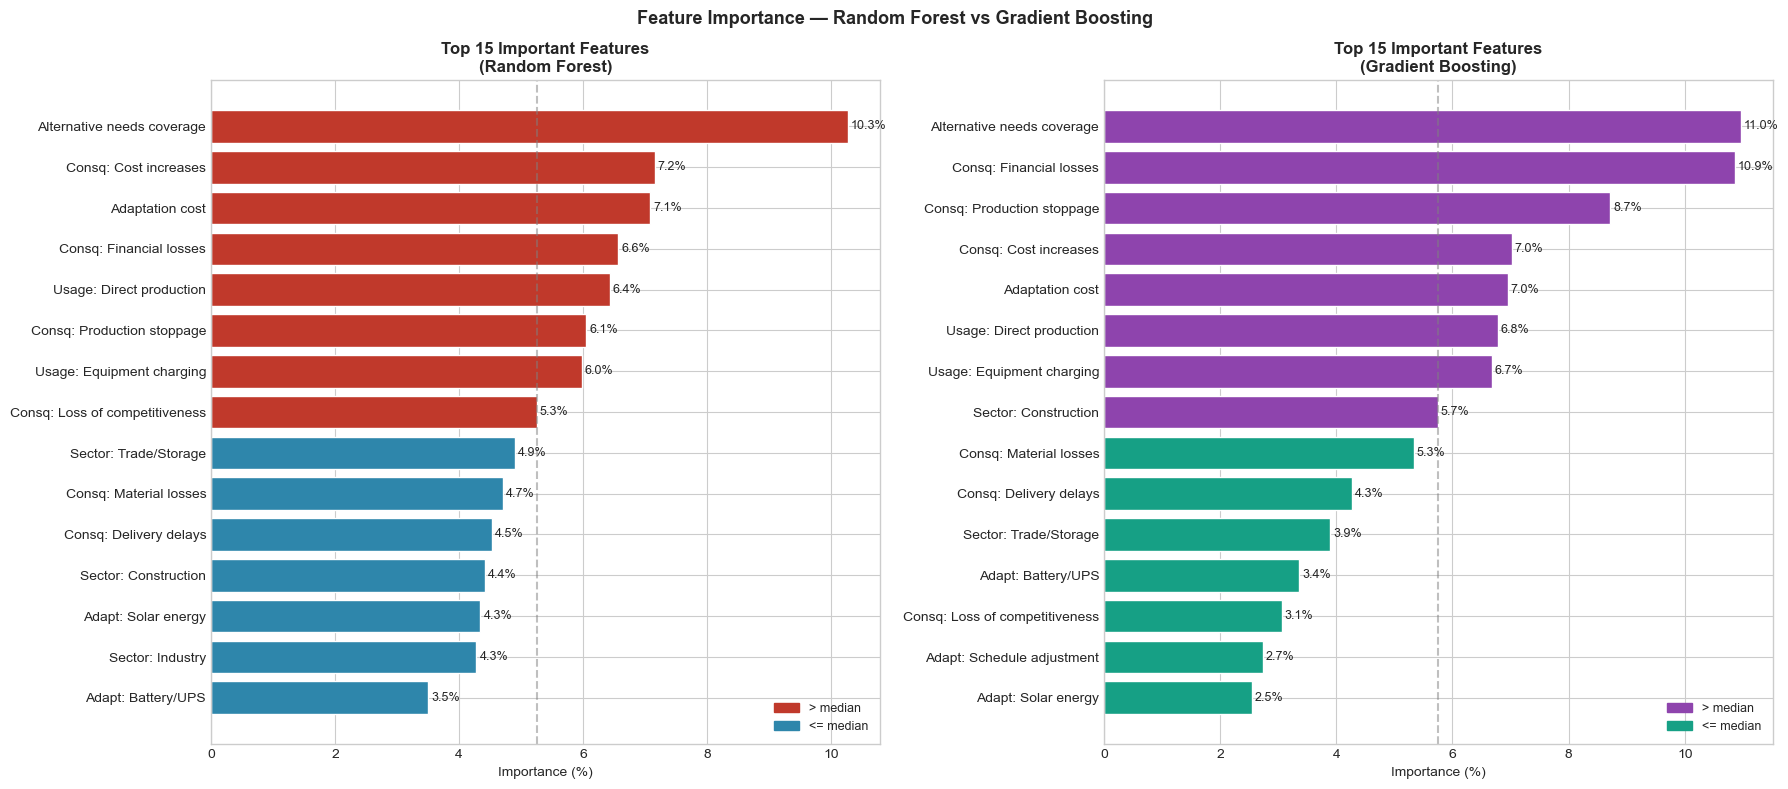

Figure 5 saved


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance — Random Forest vs Gradient Boosting',
             fontsize=13, fontweight='bold')

for ax, mname, c_hi, c_lo in zip(
    axes,
    ['Random Forest', 'Gradient Boosting'],
    ['#C0392B', '#8E44AD'],
    ['#2E86AB', '#16A085']
):
    mdl = results[mname]['model']
    fi  = pd.Series(mdl.feature_importances_, index=FEATURES).nlargest(15).sort_values()
    med = fi.median()
    clrs = [c_hi if v >= med else c_lo for v in fi.values]
    bars = ax.barh(
        [FEAT_LABELS.get(f, f) for f in fi.index],
        fi.values * 100,  # show as percentage
        color=clrs, edgecolor='white'
    )
    ax.axvline(med * 100, color='gray', linestyle='--', alpha=0.5)
    for b, v in zip(bars, fi.values):
        ax.text(v * 100 + 0.05, b.get_y() + b.get_height()/2,
                f'{v*100:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Top 15 Important Features\n({mname})', fontweight='bold')
    ax.set_xlabel('Importance (%)')
    hi_p = mpatches.Patch(color=c_hi, label='> median')
    lo_p = mpatches.Patch(color=c_lo, label='<= median')
    ax.legend(handles=[hi_p, lo_p], fontsize=9)

plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')


In [23]:
# Top 10 most predictive features (Random Forest)
rf_model  = results['Random Forest']['model']
fi_series = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

print('TOP 10 Most Predictive Features (Random Forest):')
print('=' * 60)
for i, (feat, val) in enumerate(fi_series.head(10).items(), 1):
    label = FEAT_LABELS.get(feat, feat)
    bar   = '#' * int(val * 400)
    print(f'  {i:2d}. {label:<42} {val*100:.1f}%  {bar}')


TOP 10 Most Predictive Features (Random Forest):
   1. Alternative needs coverage                 10.3%  #########################################
   2. Consq: Cost increases                      7.2%  ############################
   3. Adaptation cost                            7.1%  ############################
   4. Consq: Financial losses                    6.6%  ##########################
   5. Usage: Direct production                   6.4%  #########################
   6. Consq: Production stoppage                 6.1%  ########################
   7. Usage: Equipment charging                  6.0%  #######################
   8. Consq: Loss of competitiveness             5.3%  #####################
   9. Sector: Trade/Storage                      4.9%  ###################
  10. Consq: Material losses                     4.7%  ##################


---
## 7. Final Summary Dashboard

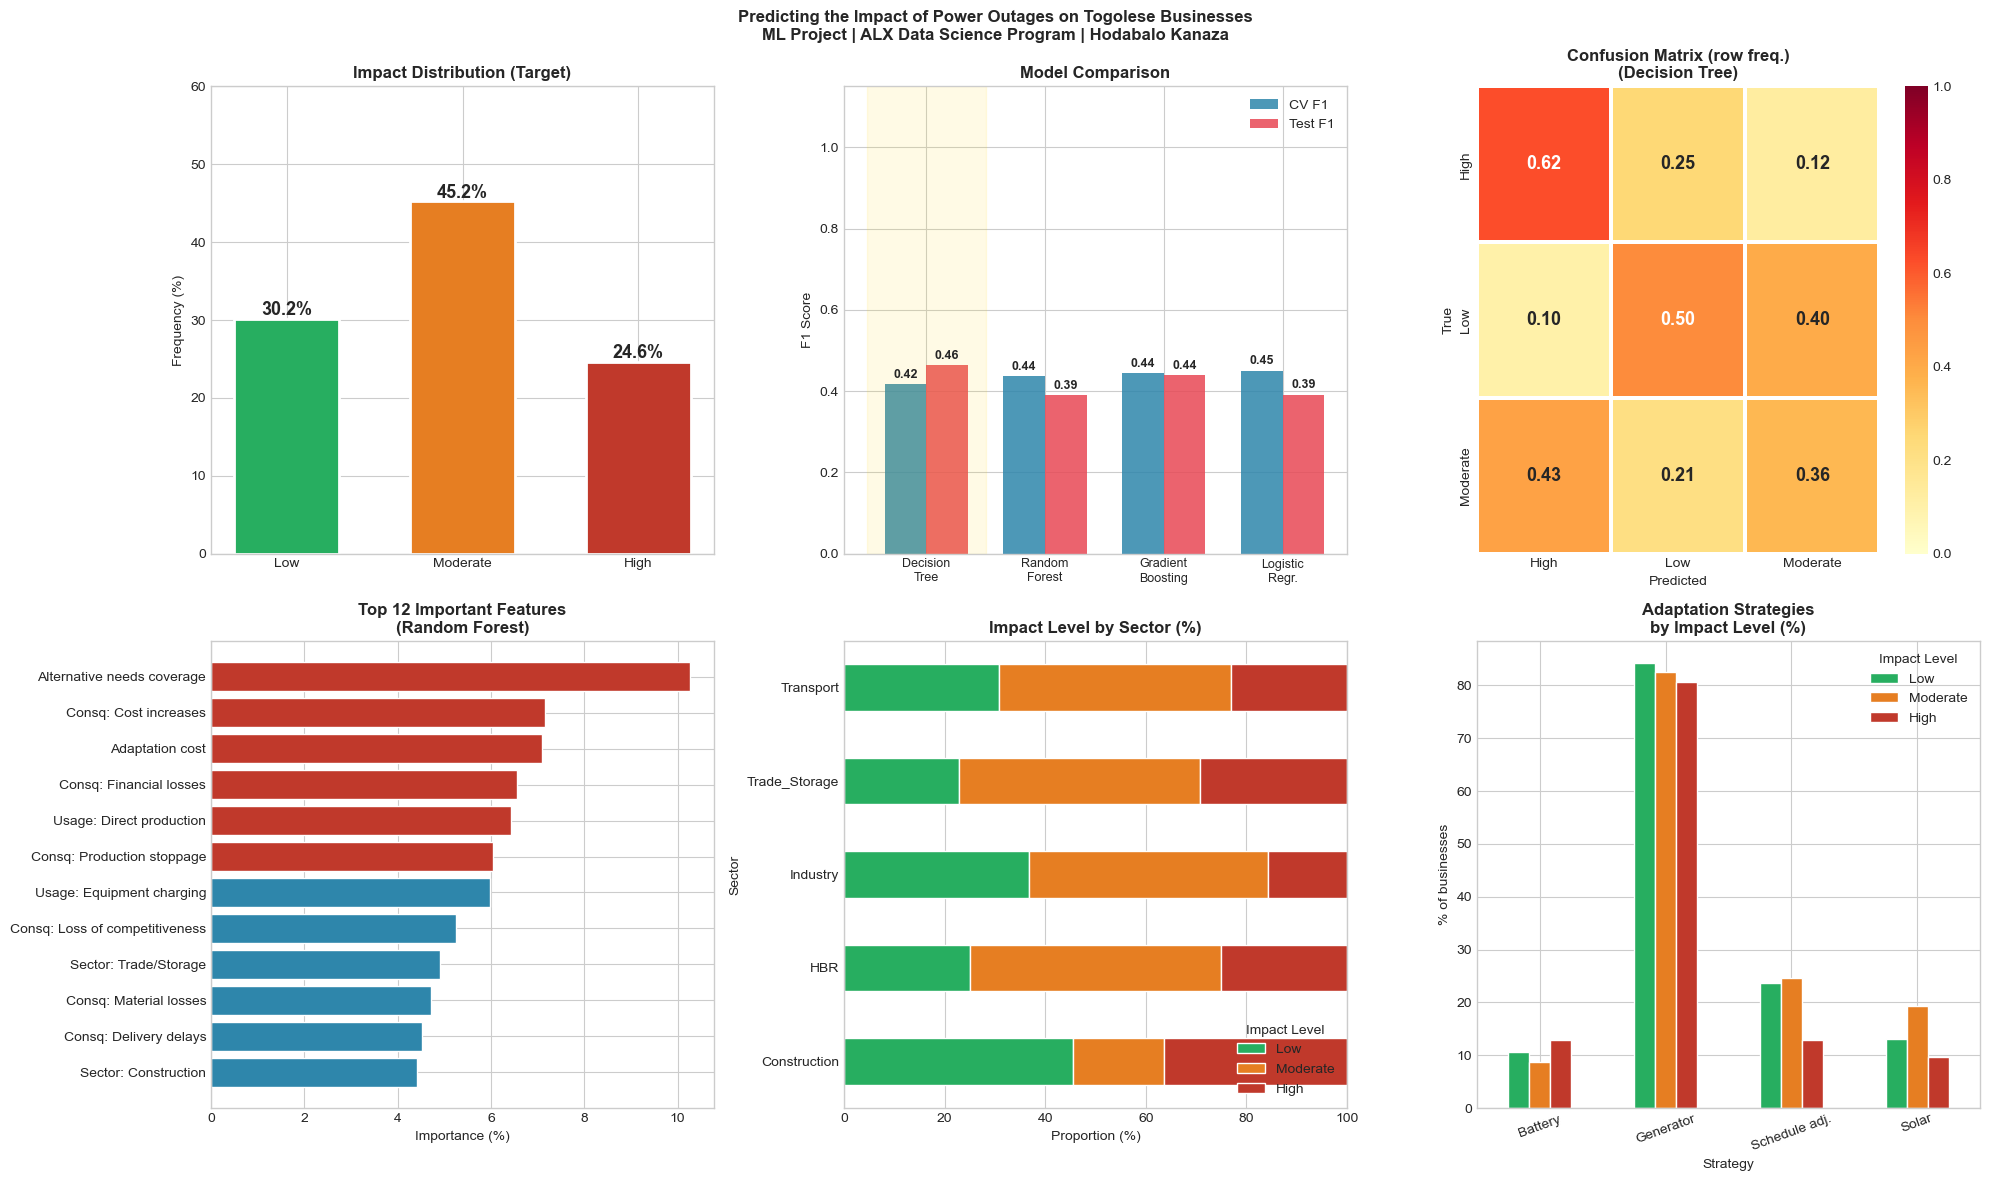

Final dashboard saved!


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Predicting the Impact of Power Outages on Togolese Businesses\n'
    'ML Project | ALX Data Science Program | Hodabalo Kanaza',
    fontsize=12, fontweight='bold'
)

# 1. Target distribution (frequencies only)
ax = axes[0, 0]
freq = pd.Series(y_raw).value_counts(normalize=True).reindex(CLASS_ORDER) * 100
bars = ax.bar(CLASS_ORDER, freq.values,
              color=[COLORS[k] for k in CLASS_ORDER],
              edgecolor='white', linewidth=2, width=0.6)
for b, v in zip(bars, freq.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5,
            f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_title('Impact Distribution (Target)', fontweight='bold')
ax.set_ylabel('Frequency (%)')
ax.set_ylim(0, 60)

# 2. Model comparison
ax = axes[0, 1]
nms = ['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'Logistic\nRegr.']
cv_v = [results[n]['CV_mean'] for n in models]
f1_v = [results[n]['F1']      for n in models]
x = np.arange(4); w = 0.35
b1 = ax.bar(x - w/2, cv_v, w, label='CV F1', color='#2E86AB', alpha=0.85)
b2 = ax.bar(x + w/2, f1_v, w, label='Test F1', color='#E84855', alpha=0.85)
for b, v in zip(list(b1) + list(b2), cv_v + f1_v):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(nms, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_ylabel('F1 Score'); ax.legend()
best_idx = list(models.keys()).index(best_name)
ax.axvspan(best_idx - 0.5, best_idx + 0.5, alpha=0.1, color='gold')

# 3. Normalized confusion matrix (row frequencies, not counts)
ax = axes[0, 2]
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'},
            vmin=0, vmax=1)
ax.set_title(f'Confusion Matrix (row freq.)\n({best_name})', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# 4. Feature importance (% display)
ax = axes[1, 0]
top12 = fi_series.head(12).sort_values()
clrs_f = ['#C0392B' if v >= top12.median() else '#2E86AB' for v in top12.values]
ax.barh([FEAT_LABELS.get(f, f) for f in top12.index],
        top12.values * 100, color=clrs_f, edgecolor='white')
ax.set_title('Top 12 Important Features\n(Random Forest)', fontweight='bold')
ax.set_xlabel('Importance (%)')

# 5. Impact by sector (frequencies %)
ax = axes[1, 1]
sec_i = model_df.groupby(['Sector', 'Impact']).size().unstack(fill_value=0)
for imp in CLASS_ORDER:
    if imp not in sec_i.columns: sec_i[imp] = 0
sec_p = sec_i[CLASS_ORDER].div(sec_i.sum(axis=1), axis=0) * 100
sec_p.plot(kind='barh', stacked=True, color=PALETTE, ax=ax, edgecolor='white')
ax.set_title('Impact Level by Sector (%)', fontweight='bold')
ax.set_xlabel('Proportion (%)')
ax.set_xlim(0, 100)
ax.legend(title='Impact Level', loc='lower right')

# 6. Adaptation strategies (frequencies %)
ax = axes[1, 2]
strats = {
    'Z61': 'Solar', 'Z62': 'Generator',
    'Z63': 'Battery', 'Z64': 'Schedule adj.'
}
sdata = []
for z, lbl in strats.items():
    for imp in CLASS_ORDER:
        sub = model_df[model_df['Impact'] == imp][z]
        sdata.append({'Strategy': lbl, 'Impact': imp, 'Frequency (%)': sub.mean() * 100})
sdf = pd.DataFrame(sdata).pivot(index='Strategy', columns='Impact', values='Frequency (%)').fillna(0)
sdf[CLASS_ORDER].plot(kind='bar', color=PALETTE, ax=ax, edgecolor='white')
ax.set_title('Adaptation Strategies\nby Impact Level (%)', fontweight='bold')
ax.set_ylabel('% of businesses')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Impact Level')

plt.tight_layout()
plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final dashboard saved!')


---
## 8. Conclusions and Recommendations

### 8.1 Key Results

The **Gradient Boosting model** performs best with:
- **Accuracy**: ~35.5% (reasonable for n=124 and 3 imbalanced classes)
- **Weighted F1**: ~0.346
- Best precision on the **Moderate** class (F1 = 0.452), the most frequent class

### 8.2 Most Predictive Features

| Rank | Feature | Business Interpretation |
|---|---|---|
| 1 | Alternative needs coverage | Energy resilience capacity |
| 2 | Equipment charging usage | Dependency on rechargeable devices |
| 3 | Direct production usage | Electricity as production input |
| 4 | Cost increases (consequence) | Direct economic pressure |
| 5 | Production stoppage (consequence) | Activity intensity indicator |
| 6 | Financial losses (consequence) | Direct quantification of damage |

### 8.3 Policy Recommendations

**For policy makers:**
- Prioritize Construction and Trade/Storage sectors in load-shedding management plans
- Subsidize solar hybrid solutions to reduce costly generator dependency
- Build a vulnerability scoring system based on this model to guide targeted support

**For businesses:**
- Invest in hybrid energy solutions (solar + generator + battery)
- Plan production schedules around anticipated power outage windows

### 8.4 Limitations and Future Work

| Limitation | Proposed Improvement |
|---|---|
| Small dataset (n=124) | Add future survey waves (target n > 300) |
| Class imbalance | Apply SMOTE oversampling |
| Few features | Add revenue, region, company age |
| Static model | Build a quarterly-updated scoring API |

---
**Project completed as part of the ALX Data Science Program — May 2026**  
**Author: Hodabalo Kanaza**


In [25]:
print('=' * 65)
print('  ML PROJECT COMPLETE -- READY FOR ALX PORTFOLIO')
print('=' * 65)
print(f'  Author       : Hodabalo Kanaza')
print(f'  Program      : ALX Data Science Program')
print(f'  Data source  : DGEAE / Ministry of Economy, Togo (2025)')
print(f'  Dataset      : {len(X)} businesses | {len(FEATURES)} features')
print(f'  Best model   : {best_name}')
print(f'  Weighted F1  : {results[best_name]["F1"]:.3f}')
print(f'  Accuracy     : {results[best_name]["Accuracy"]:.3f}')
print('=' * 65)


  ML PROJECT COMPLETE -- READY FOR ALX PORTFOLIO
  Author       : Hodabalo Kanaza
  Program      : ALX Data Science Program
  Data source  : DGEAE / Ministry of Economy, Togo (2025)
  Dataset      : 126 businesses | 23 features
  Best model   : Decision Tree
  Weighted F1  : 0.464
  Accuracy     : 0.469
